<a href="https://colab.research.google.com/github/KarolinaBatogowska/projekt-klasyfikacja-stres/blob/main/projekt_klasyfikacja_stres.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Ładowanie i eksploracja danych

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

!wget https://raw.githubusercontent.com/KarolinaBatogowska/projekt-klasyfikacja-stres/refs/heads/main/Teen_Mental_Health_Dataset.csv


--2026-06-09 18:49:59--  https://raw.githubusercontent.com/KarolinaBatogowska/projekt-klasyfikacja-stres/refs/heads/main/Teen_Mental_Health_Dataset.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.110.133, 185.199.111.133, 185.199.108.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.110.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 62496 (61K) [text/plain]
Saving to: ‘Teen_Mental_Health_Dataset.csv’

Teen_Mental_Health_ 100%[===================>]  61.03K  --.-KB/s    in 0.003s  

2026-06-09 18:50:00 (18.4 MB/s) - ‘Teen_Mental_Health_Dataset.csv’ saved [62496/62496]



In [2]:
# Definicja funkcji wczytującej dane

def load_stress_data(data_path="Teen_Mental_Health_Dataset.csv"):
    return pd.read_csv(data_path)

df = load_stress_data()

In [3]:
# Wyświetlenie informacji o kolumnach, typach danych i brakach (odpowiednik housing.info())

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   age                       1200 non-null   int64  
 1   gender                    1200 non-null   object 
 2   daily_social_media_hours  1200 non-null   float64
 3   platform_usage            1200 non-null   object 
 4   sleep_hours               1200 non-null   float64
 5   screen_time_before_sleep  1200 non-null   float64
 6   academic_performance      1200 non-null   float64
 7   physical_activity         1200 non-null   float64
 8   social_interaction_level  1200 non-null   object 
 9   stress_level              1200 non-null   int64  
 10  anxiety_level             1200 non-null   int64  
 11  addiction_level           1200 non-null   int64  
 12  depression_label          1200 non-null   int64  
dtypes: float64(5), int64(5), object(3)
memory usage: 122.0+ KB


In [4]:
df.describe()

,age,daily_social_media_hours,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,stress_level,anxiety_level,addiction_level,depression_label
count,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000
mean,15.928333,4.536667,6.449417,1.740333,2.990383,1.014500,5.445833,5.636667,5.565000,0.025833
std,2.021947,2.029599,1.442677,0.716660,0.576758,0.582185,2.903290,2.859453,2.830627,0.158704
min,13.000000,1.000000,4.000000,0.500000,2.000000,0.000000,1.000000,1.000000,1.000000,0.000000
25%,14.000000,2.800000,5.200000,1.100000,2.500000,0.500000,3.000000,3.000000,3.000000,0.000000
50%,16.000000,4.500000,6.500000,1.800000,2.990000,1.000000,5.000000,6.000000,6.000000,0.000000
75%,18.000000,6.300000,7.600000,2.400000,3.480000,1.500000,8.000000,8.000000,8.000000,0.000000
max,19.000000,8.000000,9.000000,3.000000,4.000000,2.000000,10.000000,10.000000,10.000000,1.000000


In [11]:
# 1. Definicja BEZPIECZNEJ funkcji grupującej
def group_stress(value):
    if value in [0, 1, 2]:
        return value

    # Oryginalna skala 1-10
    if value <= 4:
         return 0  # Niski stres
    elif value <= 7:
         return 1  # Średni stres
    else:
         return 2  # Wysoki stres

# 2. Mapowanie
df["stress_level"] = df["stress_level"].apply(group_stress)

print(df["stress_level"].value_counts())

stress_level
1    483
2    462
0    255
Name: count, dtype: int64


In [13]:
# Sprawdzenie jakie wartości i w jakiej ilości przyjmuje kolumna z poziomem stresu

df["stress_level"].value_counts()

,count
stress_level,
1,483
2,462
0,255


In [14]:
from sklearn.model_selection import train_test_split

# 1. Podział danych ze stratyfikacją
train_set, test_set = train_test_split(df, test_size=0.2, random_state=42, stratify=df['stress_level'])

# 2. Sprawdzenie liczby wierszy w zbiorach (Twoja komórka)
print("Train size:", len(train_set))
print("Test size:", len(test_set))

# 3. Sprawdzenie balansu klas w zbiorze treningowym
print(train_set["stress_level"].value_counts())

Train size: 960
Test size: 240
stress_level
1    386
2    370
0    204
Name: count, dtype: int64


/tmp/ipykernel_12929/3502726484.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=train_set, x='stress_level', palette='Set2')


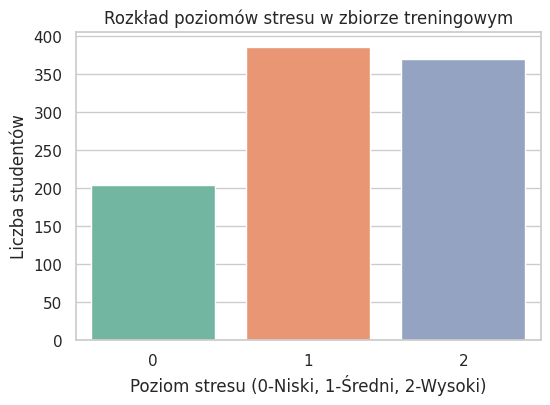

/tmp/ipykernel_12929/3502726484.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=train_set, x='stress_level', y='sleep_hours', palette='Pastel1')


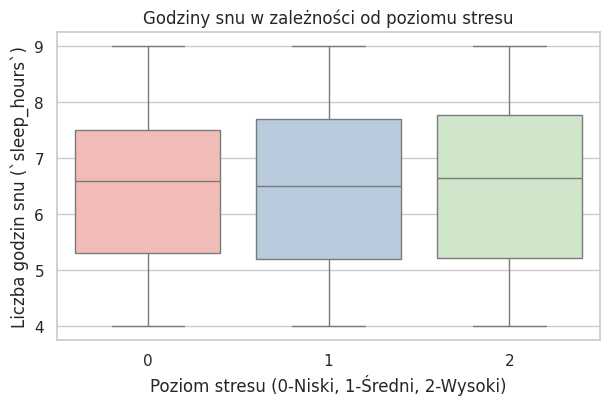

/tmp/ipykernel_12929/3502726484.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=train_set, x='stress_level', y='screen_time_before_sleep', palette='Pastel2')


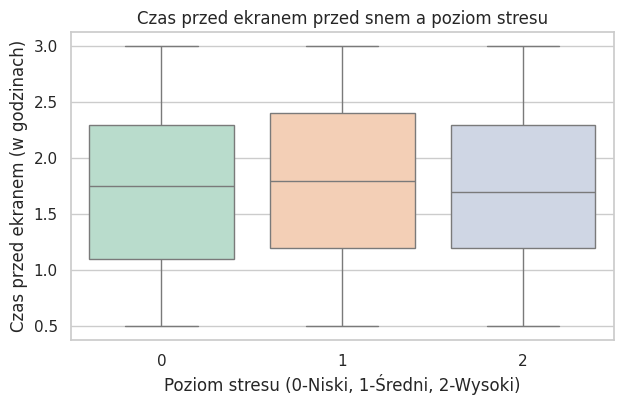

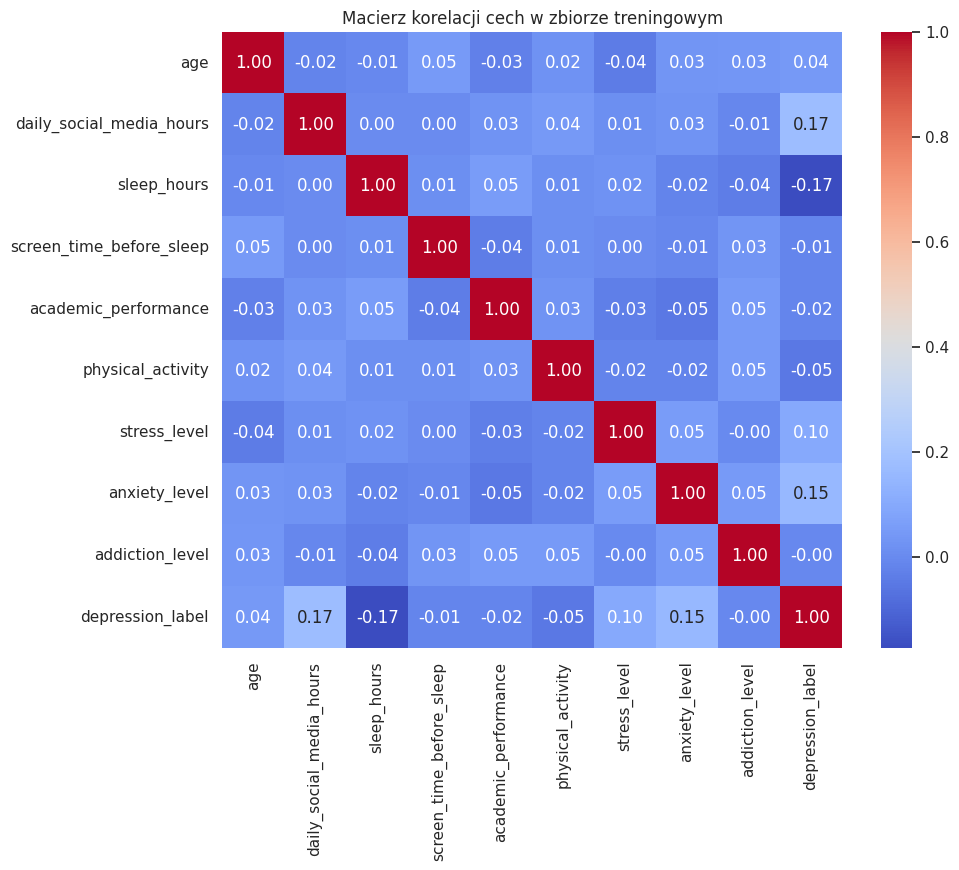

In [17]:
# Tworzymy bezpieczną kopię zbioru treningowego do wykresów
social_media = train_set.copy()

# Ustawienie globalnego stylu wykresów
sns.set_theme(style="whitegrid")

# WYKRES 1: Rozkład poziomu stresu w zbiorze treningowym
plt.figure(figsize=(6, 4))
sns.countplot(data=train_set, x='stress_level', palette='Set2')
plt.title('Rozkład poziomów stresu w zbiorze treningowym')
plt.xlabel('Poziom stresu (0-Niski, 1-Średni, 2-Wysoki)')
plt.ylabel('Liczba studentów')
plt.show()

# WYKRES 2: Zależność między czasem snu a stresem
plt.figure(figsize=(7, 4))
sns.boxplot(data=train_set, x='stress_level', y='sleep_hours', palette='Pastel1')
plt.title('Godziny snu w zależności od poziomu stresu')
plt.xlabel('Poziom stresu (0-Niski, 1-Średni, 2-Wysoki)')
plt.ylabel('Liczba godzin snu (`sleep_hours`)')
plt.show()

# WYKRES 3: Zależność między czasem przed ekranem a stresem (DODATKOWY BONUS)
plt.figure(figsize=(7, 4))
sns.boxplot(data=train_set, x='stress_level', y='screen_time_before_sleep', palette='Pastel2')
plt.title('Czas przed ekranem przed snem a poziom stresu')
plt.xlabel('Poziom stresu (0-Niski, 1-Średni, 2-Wysoki)')
plt.ylabel('Czas przed ekranem (w godzinach)')
plt.show()

# WYKRES 4: Macierz korelacji
plt.figure(figsize=(10, 8))
corr_matrix = train_set.corr(numeric_only=True)
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Macierz korelacji cech w zbiorze treningowym')
plt.show()

In [19]:
# X_train to wszystkie kolumny OPRÓCZ poziomu stresu (cechy)
X_train = train_set.drop("stress_level", axis=1)

# y_train to tylko kolumna z poziomem stresu (zmienna docelowa)
y_train = train_set["stress_level"].copy()

In [20]:
import numpy as np
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

# Automatyczny wybór kolumn numerycznych i tekstowych
num_attribs = X_train.select_dtypes(include=[np.number]).columns.tolist()
cat_attribs = X_train.select_dtypes(include=[object, 'category']).columns.tolist()

print("Numeric columns:", num_attribs)
print("Categorical columns:", cat_attribs)

# Definicja potoków transformacji
num_pipeline = Pipeline([
    ('scaler', StandardScaler()),
])

cat_pipeline = Pipeline([
    ('onehot', OneHotEncoder(handle_unknown='ignore')),
])

# Połączenie potoków w jeden transformer
full_pipeline = ColumnTransformer([
    ("num", num_pipeline, num_attribs),
    ("cat", cat_pipeline, cat_attribs),
])

# TUTAJ TWORZY SIĘ ZMIENNA: Dopasowanie i transformacja danych wejściowych
X_train_prepared = full_pipeline.fit_transform(X_train)

print("Data prepared successfully Shape:", X_train_prepared.shape)

Numeric columns: ['age', 'daily_social_media_hours', 'sleep_hours', 'screen_time_before_sleep', 'academic_performance', 'physical_activity', 'anxiety_level', 'addiction_level', 'depression_label']
Categorical columns: ['gender', 'platform_usage', 'social_interaction_level']
Data prepared successfully Shape: (960, 17)


In [31]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# Inicjalizacja prostych modeli z automatycznym bilansowaniem klas
log_reg = LogisticRegression(random_state=42, class_weight='balanced')
forest_clf = RandomForestClassifier(random_state=42, class_weight='balanced')

# Trenowanie modeli
print("Training Logistic Regression...")
log_reg.fit(X_train_prepared, y_train)

print("Training Random Forest...")
forest_clf.fit(X_train_prepared, y_train)

print("All models trained successfully")

Training Logistic Regression...
Training Random Forest...
All models trained successfully


In [32]:
from sklearn.metrics import classification_report

# Predykcje dla regresji logistycznej
log_reg_preds = log_reg.predict(X_train_prepared)
print("=== LOGISTIC REGRESSION REPORT ===")
print(classification_report(y_train, log_reg_preds))

# Predykcje dla lasu losowego
forest_preds = forest_clf.predict(X_train_prepared)
print("\n=== RANDOM FOREST REPORT ===")
print(classification_report(y_train, forest_preds))

=== LOGISTIC REGRESSION REPORT ===
              precision    recall  f1-score   support

           0       0.25      0.39      0.30       204
           1       0.46      0.40      0.43       386
           2       0.43      0.35      0.39       370

    accuracy                           0.38       960
   macro avg       0.38      0.38      0.37       960
weighted avg       0.40      0.38      0.38       960


=== RANDOM FOREST REPORT ===
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       204
           1       1.00      1.00      1.00       386
           2       1.00      1.00      1.00       370

    accuracy                           1.00       960
   macro avg       1.00      1.00      1.00       960
weighted avg       1.00      1.00      1.00       960



In [33]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint

# Definiujemy siatkę parametrów do wylosowania
param_distribs = {
    'n_estimators': randint(low=10, high=200),
    'max_depth': randint(low=3, high=20),
    'min_samples_split': randint(low=2, high=10)
}

# Inicjalizujemy poszukiwanie (cv=3 oznacza 3-krotną walidację krzyżową)
rnd_search = RandomizedSearchCV(
    RandomForestClassifier(random_state=42),
    param_distributions=param_distribs,
    n_iter=10,
    cv=3,
    scoring='accuracy',
    random_state=42
)

print("Running Random Search (this may take a moment)...")
rnd_search.fit(X_train_prepared, y_train)

print("Best parameters found:", rnd_search.best_params_)
# Zapisujemy nasz najlepszy, dostrojony model
best_model = rnd_search.best_estimator_

Running Random Search (this may take a moment)...
Best parameters found: {'max_depth': 8, 'min_samples_split': 3, 'n_estimators': 197}


In [34]:
# 1. Rozdzielamy zbiór testowy na cechy (X) i etykietę stresu (y)
X_test = test_set.drop("stress_level", axis=1)
y_test = test_set["stress_level"].copy()

# 2. UWAGA: Dane testowe przepuszczamy TYLKO przez transform (nie fit_transform!),
# dokładnie tak jak we wzorcowym notatniku prowadzącego
X_test_prepared = full_pipeline.transform(X_test)

# 3. Przewidujemy wyniki za pomocą najlepszego modelu
final_predictions = best_model.predict(X_test_prepared)

# 4. Wyświetlamy ostateczny raport klasyfikacji
print("=== FINAL TEST SET PERFORMANCE ===")
print(classification_report(y_test, final_predictions))

=== FINAL TEST SET PERFORMANCE ===
              precision    recall  f1-score   support

           0       0.00      0.00      0.00        51
           1       0.44      0.56      0.49        97
           2       0.45      0.58      0.50        92

    accuracy                           0.45       240
   macro avg       0.30      0.38      0.33       240
weighted avg       0.35      0.45      0.39       240



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
